# Importing the Dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
import plotly.graph_objects as go
import plotly.express as px

In [3]:
modi_reviews = pd.read_csv("Modi.csv")
rahul_reviews = pd.read_csv("Rahul.csv")

In [4]:
modi_reviews.head(3)

,Unnamed: 0,User,Tweet
0,0,advosushildixit,@anjanaomkashyap I am seeing you as future #bj...
1,1,jiaeur,#LokSabhaElections2019 \n23rd May 2019 will re...
2,2,PVenkatGandhi,#LokSabhaElections2019 \n23rd May 2019 will re...


In [5]:
rahul_reviews.head(3)

,Unnamed: 0,User,Tweet
0,0,Sunnysweet16,Wonder why no academic or journalist asks INC ...
1,1,drnitinchaube,Congrats for the change #australiavotes2019 an...
2,2,mrvivek07,Peopel Say “Govt Ne 70 Years Kya kiya”.\nUnse ...


In [8]:
modi_reviews.drop(columns=['Unnamed: 0'], inplace=True)

In [9]:
rahul_reviews.drop(columns=['Unnamed: 0'], inplace=True)

In [19]:
modi_reviews.isna().sum()

User     5
Tweet    5
dtype: int64

In [21]:
modi_reviews["Tweet"] = modi_reviews["Tweet"].fillna("")

In [22]:
rahul_reviews.isna().sum()

User     0
Tweet    0
dtype: int64

# Sentiment Analysis

Now, for sentiment analysis, we will be using the Textblob package in Python. Here I will use this package to perform simple text classification in either positive or negative on the basis of sentiment analysis:

1 Polarity refers to the sentiment or emotion expressed in the text, ranging from negative to positive. If polarity > 0, then it is a positive comment, else if it's polarity<0 then it is negative comment else it is neutral i.e, polarity=0. 

2 Subjectivity, suggests that the text contains some subjects or opinions, measures the extent to which the text is subjective or opinionated rather than objective

In [23]:
textblob1 = TextBlob(modi_reviews['Tweet'][10])
textblob1.sentiment
textblob2 = TextBlob(rahul_reviews['Tweet'][500])
textblob2.sentiment

Sentiment(polarity=0.0, subjectivity=0.4)

In [24]:
def find_pol(review):
    return TextBlob(review).sentiment.polarity

In [25]:
modi_reviews["Sentiment Polarity"] = modi_reviews["Tweet"].apply(find_pol)
rahul_reviews["Sentiment Polarity"] = rahul_reviews["Tweet"].apply(find_pol)

In [26]:
modi_reviews.head(3)

,User,Tweet,Sentiment Polarity
0,advosushildixit,@anjanaomkashyap I am seeing you as future #bj...,0.35
1,jiaeur,#LokSabhaElections2019 \n23rd May 2019 will re...,0.80
2,PVenkatGandhi,#LokSabhaElections2019 \n23rd May 2019 will re...,0.80


In [27]:
rahul_reviews.head(3)

,User,Tweet,Sentiment Polarity
0,Sunnysweet16,Wonder why no academic or journalist asks INC ...,0.21875
1,drnitinchaube,Congrats for the change #australiavotes2019 an...,0.00000
2,mrvivek07,Peopel Say “Govt Ne 70 Years Kya kiya”.\nUnse ...,0.00000


# Sentiment Polarity on both the candidates:

In [28]:
modi_reviews["Expression Label"] = np.where(modi_reviews["Sentiment Polarity"]>0, "positive", "negative")
modi_reviews.loc[modi_reviews["Sentiment Polarity"] == 0, "Expression Label"] = "Neutral"

print(modi_reviews.tail())

rahul_reviews["Expression Label"] = np.where(rahul_reviews["Sentiment Polarity"]>0, "positive", "negative")
rahul_reviews.loc[rahul_reviews["Sentiment Polarity"] == 0, "Expression Label"] = "Neutral"
print(rahul_reviews.tail())

                User                                              Tweet  \
25683     shv_indian  #1DDrive #ModiSpeaksToNews18 #LokSabhaElection...   
25684     SONUPINKOO  I am seriously worried about future of Indian ...   
25685     SONUPINKOO  If @narendramodi is so Bad then Why does @INCI...   
25686     SONUPINKOO  On this 23rd March (Pakistan Day), I Urge all ...   
25687  parthajit0101  @timesofindia #ArvindKejriwal, #AAP sirji pls ...   

       Sentiment Polarity Expression Label  
25683            0.000000          Neutral  
25684            0.209524         positive  
25685           -0.700000         negative  
25686            0.000000          Neutral  
25687           -0.213542         negative  
             User                                              Tweet  \
14256    SunjayJK  @quizzicalguy In this #LokSabhaElections2019, ...   
14257    SunjayJK  @AnumaVidisha @RahulGandhi @ArvindKejriwal whe...   
14258  RAMANKAIRA  @sherryontopp Early morning #political move 

# Drop all the tweets with neutral polarity

In [35]:
reviews1 = modi_reviews[modi_reviews['Sentiment Polarity'] == 0.0000] # Filter reviews where Sentiment Polarity is exactly 0.0000 (neutral reviews)
print(reviews1.shape)

reviews2 = rahul_reviews[rahul_reviews['Sentiment Polarity'] == 0.0000]
print(reviews2.shape)

(0, 4)
(0, 4)


There are NO rows where Sentiment Polarity == 0.0000 in either dataframe, so no need to drop anything now.

# Balance the datasets

In [36]:
modi_reviews.shape

(17482, 4)

In [37]:
rahul_reviews.shape

(9367, 4)

### Upsample the smaller dataset

In [38]:
rahul_reviews = rahul_reviews.sample(n=modi_reviews.shape[0], replace=True, random_state=42)

In [40]:
print(modi_reviews.shape)
print(rahul_reviews.shape)

(17482, 4)
(17482, 4)


# Predict the US Elections, by analyzing the number of positive and negative sentiments in both the accounts:

In [46]:
count_1 = modi_reviews.groupby('Expression Label')['Sentiment Polarity'].count() # Count the number of reviews for each 'Expression Label' in modi_reviews
percent_1 = (count_1 / count_1.sum()) * 100 # Calculate the percentage of each 'Expression Label' in modi_reviews
print(percent_1)

count_2 = rahul_reviews.groupby('Expression Label')['Sentiment Polarity'].count()
percent_2 = (count_2 / count_2.sum()) * 100
print(percent_2)

Expression Label
negative    28.846814
positive    71.153186
Name: Sentiment Polarity, dtype: float64
Expression Label
negative    33.994966
positive    66.005034
Name: Sentiment Polarity, dtype: float64


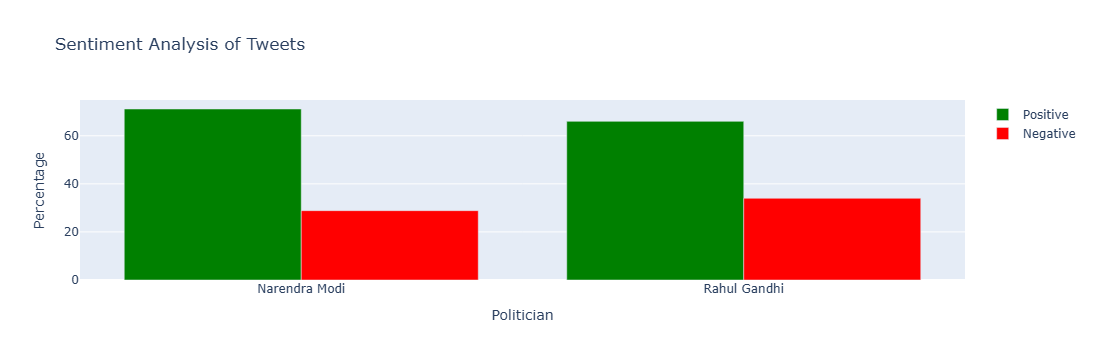

In [48]:
Politicians = ['Narendra Modi', 'Rahul Gandhi']
lis_pos = [ percent_1.get('positive', 0), percent_2.get('positive', 0)]
lis_neg = [ percent_1.get('negative', 0), percent_2.get('negative', 0)]

# Create grouped bar chart
fig = go.Figure(data=[
    go.Bar(name='Positive', x=Politicians, y=lis_pos, marker_color='green'),
    go.Bar(name='Negative', x=Politicians, y=lis_neg, marker_color='red')
])

fig.update_layout(
    title='Sentiment Analysis of Tweets',
    yaxis_title='Percentage',
    xaxis_title='Politician',
    barmode='group'
)

fig.show()